# Helper Functions

In [1]:
using Diffusions, Random, StatsBase, Flux, OneHotArrays, Distributions, Plots, Random, StatsPlots, LaTeXStrings
using Flux
using NNlib
using Random
using LinearAlgebra
include("diffusion.jl")
include("loss.jl")
include("Diffusions.jl/src/maskedarrays.jl")
rng = Random.default_rng()

TaskLocalRNG()

In [2]:
# This function runs into errors due to the Process type defined in Diffusions.jl
# Therefore, it is called here once again to resolve this error
# This problem will disappear when the MaskedDiffusionLanguageModels are integrated into the package

import Diffusions: sampleforward

function sampleforward(rng::AbstractRNG, process::Process, t::Real, x::AbstractArray)
    x = copy(x)
    maskedvec(x) .= _sampleforward(rng, process, t, maskedvec(x))
    return x
end

function sampleforward(rng::AbstractRNG, process::Process, t::AbstractVector{<:Real}, x::AbstractArray)
    x = copy(x)
    for i in axes(x, ndims(x))
        maskedvec(x, i) .= _sampleforward(rng, process, t[i], maskedvec(x, i))
    end
    return x
end


sampleforward (generic function with 6 methods)

In [3]:
import Diffusions: eq_dist
eq_dist(model::MaskedDiffusionLanguageModel) = Categorical(model.vocab_size)

eq_dist (generic function with 5 methods)

In [4]:
# These functions run into the same problems as the ones mentioned above

import Diffusions: samplebackward

function checktimesteps(timesteps)
    length(timesteps) ≥ 2 || throw(ArgumentError("timesteps must have at least two timesteps"))
    issorted(timesteps) || throw(ArgumentError("timesteps must be increasing"))
    all(>(0), timesteps) || throw(ArgumentError("all timesteps must be positive"))
end

struct NullTracker end

track!(::NullTracker, t, x, x0) = nothing


struct Tracker
    time::Vector
    data::Vector
    x0::Vector
end

Tracker() = Tracker([], [], [])

function track!(tracker::Tracker, t, x, x0)
    push!(tracker.time, t)
    push!(tracker.data, x)
    push!(tracker.x0, x0)
    return nothing
end


function samplebackward(rng::AbstractRNG, guess, process, timesteps, x; tracker=NullTracker())
    checktimesteps(timesteps)
    i = lastindex(timesteps)
    t = timesteps[i]
    while i > firstindex(timesteps)
        s = timesteps[i-1]
        x_0 = guess(x, t)
        x = endpoint_conditioned_sample(rng, process, s, t, x_0, x)
        # @show x
        # track!(tracker, s, x, x_0)
        t = s
        i -= 1
    end
    return x
end

samplebackward (generic function with 2 methods)

In [5]:
function endpoint_conditioned_sample(rng::AbstractRNG, process::Process, s::Real, t::Real, x_0::AbstractArray, x_t::AbstractArray)
    if x_t isa MaskedArray
        # x_0 inherits masked elements from x_t
        x_0 = MaskedArray(x_0, x_t.indices)
    end
    x = copy(x_t)
    maskedvec(x) .= _endpoint_conditioned_sample(rng, process, s, t, maskedvec(x_0), maskedvec(x_t))
    return x
end

endpoint_conditioned_sample(rng::AbstractRNG, process, s::Real, t::Real, x_0, x_t) =
    endpoint_conditioned_sample.(rng, process, s, t, x_0, x_t)

# sample x at time s conditioned on x_0 at time 0 and x_t at time t
endpoint_conditioned_sample(P::Process, s::Real, t::Real, x_0, x_t) = endpoint_conditioned_sample(Random.default_rng(), P, s, t, x_0, x_t)


endpoint_conditioned_sample (generic function with 3 methods)

# Loading in the Data

In [6]:
using CSV, DataFrames, JSON, CodecZlib

# Read the first line and process it
metadata_string = readline(GzipDecompressorStream(open("Data/SCoV1_M6_Sort1_1_Paired_All.csv.gz")))
metadata_string = replace(metadata_string, "\"\"" => "\"")  # Replace double quotes with single quotes
metadata_string = strip(metadata_string, '"')  # Remove the outermost quotes
metadata = JSON.parse(metadata_string)

# Read the CSV data, skipping the first line
df = CSV.File("Data/SCoV1_M6_Sort1_1_Paired_All.csv.gz", 
              skipto=3,  # Skip the metadata line
              header=2,  # Use the second line as header
              delim=',', 
              missingstring=["", "NA"],
              ignoreemptyrows=true,
              silencewarnings=true) |> DataFrame;

;
# Now you have both metadata and the DataFrame

In [99]:
@show sequence = [i for i in names(df) if occursin("aa", i) && occursin("sequence", i)];

sequence = [i for i = names(df) if occursin("aa", i) && occursin("sequence", i)] = ["sequence_alignment_aa_heavy", "v_sequence_alignment_aa_heavy", "d_sequence_alignment_aa_heavy", "j_sequence_alignment_aa_heavy", "sequence_alignment_aa_light", "v_sequence_alignment_aa_light", "d_sequence_alignment_aa_light", "j_sequence_alignment_aa_light"]


In [100]:
for name in names(df)
    println(name)
end

sequence_id_heavy
sequence_heavy
locus_heavy
stop_codon_heavy
vj_in_frame_heavy
v_frameshift_heavy
productive_heavy
rev_comp_heavy
complete_vdj_heavy
v_call_heavy
d_call_heavy
j_call_heavy
sequence_alignment_heavy
germline_alignment_heavy
sequence_alignment_aa_heavy
germline_alignment_aa_heavy
v_alignment_start_heavy
v_alignment_end_heavy
d_alignment_start_heavy
d_alignment_end_heavy
j_alignment_start_heavy
j_alignment_end_heavy
v_sequence_alignment_heavy
v_sequence_alignment_aa_heavy
v_germline_alignment_heavy
v_germline_alignment_aa_heavy
d_sequence_alignment_heavy
d_sequence_alignment_aa_heavy
d_germline_alignment_heavy
d_germline_alignment_aa_heavy
j_sequence_alignment_heavy
j_sequence_alignment_aa_heavy
j_germline_alignment_heavy
j_germline_alignment_aa_heavy
fwr1_heavy
fwr1_aa_heavy
cdr1_heavy
cdr1_aa_heavy
fwr2_heavy
fwr2_aa_heavy
cdr2_heavy
cdr2_aa_heavy
fwr3_heavy
fwr3_aa_heavy
fwr4_heavy
fwr4_aa_heavy
cdr3_heavy
cdr3_aa_heavy
junction_heavy
junction_length_heavy
junction_aa_h

# **Understanding the DataFrame**

As can be seen above, the data consists of *a lot* of different columns. Some of these consists of DNA/AA sequences whereas others describe the functionality/quality of the antibody. Here is a slight overview of what is taken into account in the following processing code. Source: Claude.ai

## What is consists of

### Quality and validity indicators:

- productive_heavy: Indicates if the sequence is productive (can potentially produce a functional antibody).
- stop_codon_heavy: Presence of premature stop codons.
- vj_in_frame_heavy: Whether the V and J genes are in-frame.
- v_frameshift_heavy: Presence of frameshifts in the V gene.
- complete_vdj_heavy: Whether the sequence has complete V, D, and J gene segments.


### Gene calls:

- v_call_heavy, d_call_heavy, j_call_heavy: The identified V, D, and J genes.


### Alignment scores and identity:

- v_score_heavy, d_score_heavy, j_score_heavy: Alignment scores for V, D, and J genes.
- v_identity_heavy, d_identity_heavy, j_identity_heavy: Percent identity to germline genes.


### CDR3 information:

- cdr3_aa_heavy: The amino acid sequence of the CDR3 region.
- cdr3_heavy: The nucleotide sequence of the CDR3 region.
- junction_length_heavy, junction_aa_length_heavy: Lengths of the junction region.


### Isotype information:

- Isotype_heavy: The antibody isotype.


### Sequence redundancy:

- Redundancy_heavy: Indicates how many times this sequence was observed.


### ANARCI information:

- ANARCI_numbering_heavy, ANARCI_status_heavy: Numbering and status from the ANARCI tool, which can provide additional structural information.

## Concluding remarks

For your diffusion task, you might want to consider filtering or weighting sequences based on some of these quality indicators. For example, you might only want to use sequences that are productive, have complete VDJ regions, and don't have stop codons or frameshifts.
Additionally, the CDR3 region (especially cdr3_aa_heavy) is often of particular interest in antibody studies as it's crucial for antigen binding.
Remember that this dataset includes both heavy and light chain information (indicated by '_heavy' and '_light' suffixes). Depending on your specific task, you might want to consider both chains or focus on one.



In [9]:
sequences = df.sequence_alignment_aa_heavy

7979-element Vector{String}:
 "QVQVVHSGAEVKRPGSSVKVSCKTSGYPFSS" ⋯ 57 bytes ⋯ "EDTAVYFCAREIPATSYFDYWGQGTLVTVSS"
 "EVQLVESGGGLVKPGGSLRLSCVGSNFPFKD" ⋯ 68 bytes ⋯ "TDRAEGFYSDVKGYTSEGHFWGQGTLVTVSS"
 "QVQLQESGPGLVKPSETLSLTCTVSGGSMSR" ⋯ 56 bytes ⋯ "ADTAVYYCARVNYYESYFEYWGQGSLLTVSS"
 "QMQLVESGGGVVQPGKSLRLSCAASGFTFYN" ⋯ 63 bytes ⋯ "YCAKVVTPYDYADPDNWLDPWGQGTLVTVSS"
 "QVQLQESGPGLVKPSQTLSLTCTVSGGSISS" ⋯ 63 bytes ⋯ "YYCASGSYYDILVPPYGMDVWGQGTTVTVSS"
 "EVQLLESGGGLVQPGGSLRLSCAASGFTFSS" ⋯ 63 bytes ⋯ "YCAKPPGRFWSGYYGCGMDVWGQGTTVTVSS"
 "EVHLVQSGGEVKKPGESLRISCQASGYSFTN" ⋯ 60 bytes ⋯ "AKYYCARLIQTGAAAGTFDNWGQGTLVTVSS"
 "QVQLVQSGAEVKKPGASVKVSCKTSGYTLTN" ⋯ 55 bytes ⋯ "ISDDTAVYFCATVYSHGPETWGQGTLVTVSS"
 "DVQLLESGGGLVQPGGSLRLSCAASGFTFAS" ⋯ 65 bytes ⋯ "ARWTVAGRGADFYYSYGMDVWGQGTTVTVSS"
 "QVQLVESGGGVVQPGRSLRLSCATSGFTFKN" ⋯ 60 bytes ⋯ "AVYYCARDQNSGSYPGALDYWGQGTLVTVSP"
 "QVQLVQSGAEVKKPGASVKVSCKASGYTFTG" ⋯ 58 bytes ⋯ "DTAVYYCARTSSWYHYGMDVWGQGTTVTVSS"
 "VQLVESGGGLVEPGGSLRLSCAASGFRFHTA" ⋯ 55 bytes ⋯ "LKTDDTAVYYCATDRGDLDN

# Processing the Data

In [7]:
# TO PREVENT STACK OVERFLOW
df = df[1:50, :];

In [8]:
# Assuming df is your DataFrame with the antibody sequences
sequences = df.sequence_alignment_aa_heavy

# Determine unique amino acids and create a mapping
unique_aas = sort(unique(collect(Iterators.flatten(sequences))))
aa_to_index = Dict(aa => i for (i, aa) in enumerate(unique_aas))

# Determine the alphabet size
alph = length(aa_to_index)

# Function to convert a sequence to indices
function seq_to_indices(seq, aa_to_index)
    return [get(aa_to_index, aa, 1) for aa in seq]  # Use 1 as default if aa not found
end

seq_to_indices (generic function with 1 method)

In [9]:
function sample_sequences(df, batch_size, aa_to_index, alph)
    indices = rand(1:nrow(df), batch_size)
    seqs = df.sequence_alignment_aa_heavy[indices]
    max_length = maximum(length.(seqs))
    
    # Use 0 as the index for padding
    x = zeros(Int, max_length, batch_size)
    for (i, seq) in enumerate(seqs)
        indices = seq_to_indices(seq, aa_to_index)
        x[1:length(indices), i] = indices
    end
    
    # Create a 3D array: (vocab_size, seq_length, batch_size)
    return onehotbatch(x, 0:alph+1)
end

sample_sequences (generic function with 1 method)

# Testing (old)

In [76]:
timesteps = timeschedule(exp, Float32(0.001), Float32(1.0), 100)
P = MaskedDiffusionLanguageModel(alph, 5, cosineschedule)

opt = Flux.Optimiser(WeightDecay(0.0001), Adam(0.001))
# params = Flux.params(model)

Flux.Optimise.Optimiser(Any[WeightDecay(0.0001), Adam(0.001, (0.9, 0.999), 1.0e-8, IdDict{Any, Any}())])

In [79]:
batch_size = 1
datOH = sample_sequences(df, batch_size, aa_to_index, alph)

T = rand(timesteps)
diffusedOH = sampleforward(P, T, datOH)

20×119×1 Array{Bool, 3}:
[:, :, 1] =
 0  0  0  0  0  0  0  0  1  0  0  0  0  …  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  1  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  1  0  0  0  0  0  …  0  0  1  0  1  0  0  0  0  0  0  0
 0  0  0  0  0  1  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  1  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  1  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0  …  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0 

# Diffusion Transformer

In [10]:
using Flux, Functors
using NeuralAttentionlib
using NeuralAttentionlib: multihead_qkv_attention, CausalMask, with_rotary_position_embedding

struct TimestepEmbedder
    mlp::Chain
    freqs::Vector{Float32}
end

function TimestepEmbedder(dim::Int; max_period::Float32 = 10000f0)
    half = div(dim, 2)
    freqs = exp.(-log(max_period) * Float32.(range(0, 1, length=half)) / half)
    TimestepEmbedder(
        Chain(
            Dense(dim, dim * 4, relu),
            Dense(dim * 4, dim)
        ),
        freqs
    )
end

function timestep_embedding(t::Real, freqs::Vector{Float32})
    args = t .* freqs
    embedding = vcat(sin.(args), cos.(args))
    if length(freqs) * 2 < length(embedding)
        embedding = vcat(embedding, zero(t))
    end
    return Float32.(embedding)
end

function (te::TimestepEmbedder)(t::Real)
    t_freq = timestep_embedding(t, te.freqs)
    return te.mlp(t_freq)
end

struct AdaLN
    norm::LayerNorm
    shift::Dense
    scale::Dense
end

function AdaLN(dim::Int, cond_dim::Int)
    AdaLN(
        LayerNorm(dim),
        Dense(cond_dim, dim),
        Dense(cond_dim, dim)
    )
end

function (aln::AdaLN)(x::AbstractArray, cond::AbstractVector)
    normalized = aln.norm(x)
    shift = aln.shift(cond)
    scale = aln.scale(cond)
    return normalized .* (1 .+ reshape(scale, :, 1, 1)) .+ reshape(shift, :, 1, 1)
end

struct MultiheadAttention{Q,K,V,O}
    head::Int
    future::Bool
    iqproj::Q
    ikproj::K
    ivproj::V
    oproj::O
    rope_dim::Int
end

Functors.@functor MultiheadAttention (iqproj, ikproj, ivproj, oproj)

function MultiheadAttention(head, hidden_size, head_size; future = true)
    MultiheadAttention(head, future,
        Dense(hidden_size, head_size * head),
        Dense(hidden_size, head_size * head),
        Dense(hidden_size, head_size * head),
        Dense(head_size * head, hidden_size),
        head_size
    )
end

function (mha::MultiheadAttention)(q, k, v)
    qkv_attention = x -> multihead_qkv_attention(mha.head,
        mha.iqproj(x[1]), mha.ikproj(x[2]), mha.ivproj(x[3]),
        mha.future ? nothing : CausalMask())
    
    rotary_qkv_attention = x -> with_rotary_position_embedding(mha.rope_dim, qkv_attention(x))
    
    return mha.oproj(rotary_qkv_attention((q, k, v)))
end

struct TransformerLayer
    attention::MultiheadAttention
    ff::Chain
    norm1::AdaLN
    norm2::AdaLN
end

function TransformerLayer(dim::Int, n_head::Int, cond_dim::Int)
    TransformerLayer(
        MultiheadAttention(n_head, dim, dim ÷ n_head),
        Chain(
            Dense(dim, dim*4, gelu),
            Dense(dim*4, dim)
        ),
        AdaLN(dim, cond_dim),
        AdaLN(dim, cond_dim)
    )
end

function (layer::TransformerLayer)(x::AbstractArray, c::AbstractVector)
    normalized = layer.norm1(x, c)
    attention_output = layer.attention(normalized, normalized, normalized)
    x = x + attention_output
    x = x + layer.ff(layer.norm2(x, c))
    return x
end

mutable struct DIT
    token_embed::Dense
    time_embed::TimestepEmbedder
    layers::Vector{TransformerLayer}
    final_norm::AdaLN
    final_layer::Dense
end

Functors.@functor DIT

function DIT(vocab_size::Int, seq_len::Int, dim::Int, n_layers::Int, n_heads::Int, cond_dim::Int)
    DIT(
        Dense(vocab_size, dim, bias=false),
        TimestepEmbedder(cond_dim),
        [TransformerLayer(dim, n_heads, cond_dim) for _ in 1:n_layers],
        AdaLN(dim, cond_dim),
        Dense(dim, vocab_size)
    )
end

function (model::DIT)(x::AbstractArray, t::Real)
    x = model.token_embed(x)
    c = model.time_embed(t)
    
    for layer in model.layers
        x = layer(x, c)
    end
    
    x = model.final_norm(x, c)
    return model.final_layer(x)
end

# Training

In [12]:
# Get a sample batch to determine the maximum sequence length
sample_batch = sample_sequences(df, 64, aa_to_index, alph)
seq_len, batch_size = size(sample_batch)[2:3]

batch_size = 4

vocab_size = alph + 2 # This includes 0 for padding and 1 to alph for amino acids
dim = 256  # or whatever dimension you prefer
n_layers = 6  # adjust as needed
n_heads = 8   # adjust as needed
cond_dim = 256  # adjust as needed

model = DIT(vocab_size, seq_len, dim, n_layers, n_heads, cond_dim);

In [13]:
timesteps = timeschedule(exp, Float32(0.001),Float32(1.0),100)
cumu_loss = 0
training_losses = []
P = MaskedDiffusionLanguageModel(vocab_size, vocab_size, cosineschedule)

opt = Flux.Optimiser(WeightDecay(0.0001), Adam(0.001))#Adam(0.001))
params = Flux.params(model);

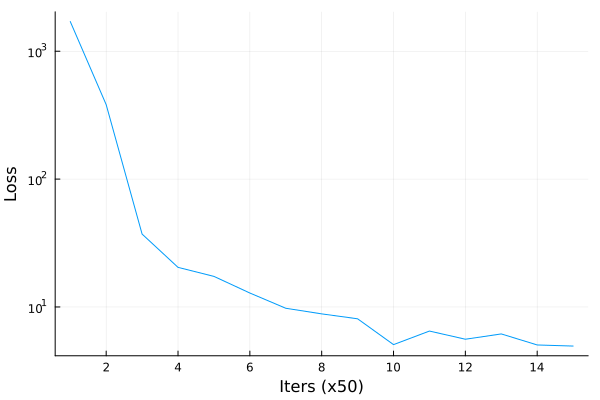

LoadError: InterruptException:

In [54]:
for iter in 1:5_000_000
    datOH = sample_sequences(df, batch_size, aa_to_index, alph)


    T = rand(timesteps)
    diffusedOH = sampleforward(P, T, datOH)
    
    # Forward pass and loss computation
    loss, grads = Flux.withgradient(params) do
        output = model(diffusedOH, T)
        -standardloss(P, T, model(diffusedOH, T), datOH)[1]
    end
    
    # Update parameters
    Flux.update!(opt, params, grads)

    cumu_loss += loss
    if mod(iter,50) == 0
        opt[2].eta = opt[2].eta * 0.997
        push!(training_losses, cumu_loss/50)  # Changed from 100 to 50 to match the iteration count
        cumu_loss = 0.0
        IJulia.clear_output(true)
        plot(training_losses, yscale = :log10, ylabel = "Loss", xlabel = "Iters (x50)", label = :none) |> IJulia.display
        sleep(0.01)
    end
    
end

# Evalutation

In [55]:
function zero_sample(x_t, t)
    vocab_size, seq_length, batch_size = size(x_t)
    
    # Ensure vocab_size is correct
    @assert vocab_size == alph + 2 "Vocabulary size mismatch"
    
    sm = softmax(model(x_t, t))
    sampled = zeros(Bool, vocab_size, seq_length, batch_size)
    
    for b in 1:batch_size
        for s in 1:seq_length
            probs = sm[:, s, b]
            sampled_token = rand(Categorical(probs)) - 1  # Subtract 1 to shift range to 0:21
            # Use 0:alph+1 to match the range in sample_sequences
            sampled[:, s, b] = onehotbatch([sampled_token], 0:alph+1)
        end
    end
    
    return sampled
end

zero_sample (generic function with 1 method)

In [56]:
N = 12 # Number of samples
seq_length = size(sample_sequences(df, 1, aa_to_index, alph), 2)

# Initialize x_T with all tokens set to the mask token index (alph + 1)
x_T = falses(vocab_size, seq_length, N)
x_T[end, :, :] .= true

# Debug prints
println("Size of x_T: ", size(x_T))
println("vocab_size: ", vocab_size)
println("alph: ", alph)
println("Range used in onehotbatch: 0:", alph+1)

@time generated_samples = samplebackward(zero_sample, P, timesteps, x_T)

Size of x_T: (22, 119, 12)
vocab_size: 22
alph: 20
Range used in onehotbatch: 0:21
 31.535624 seconds (1.74 M allocations: 29.864 GiB, 8.59% gc time, 0.16% compilation time: 100% of which was recompilation)


22×119×12 BitArray{3}:
[:, :, 1] =
 0  0  0  0  0  0  0  0  0  1  0  0  0  …  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  1  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  1  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  1  0  0  0  0  0  0  0  0  0  0  …  0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  1  0  0  0  0  1  0  0     0  0  1  0  0  0  1  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 1  0  0  0  0  0  1  0  1  0  0  0  0  …  0  0  0  0  0  0  0  1  0  0  0  0
 0  0  0  0  0  0  0  0  0  0  0  0  0     0  0  0  0  0  0  0  0  0  0  0  0
 0  0  0  0  0  0  0  0  0  0

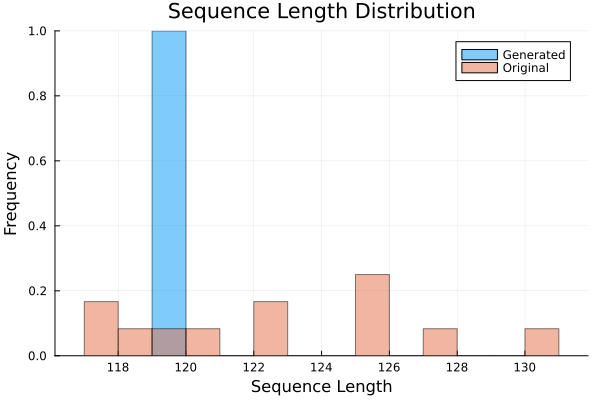

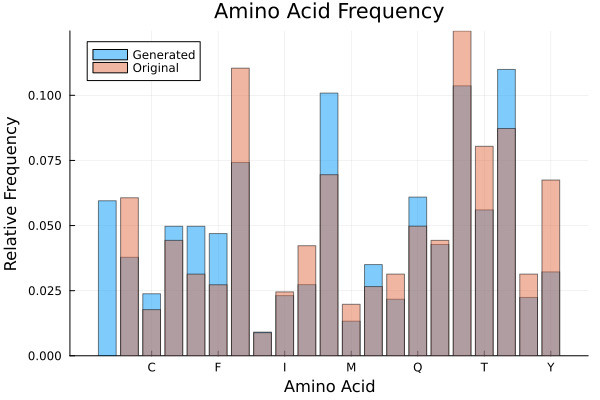

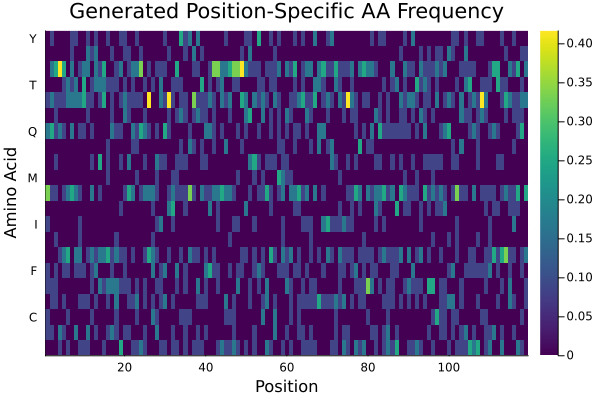

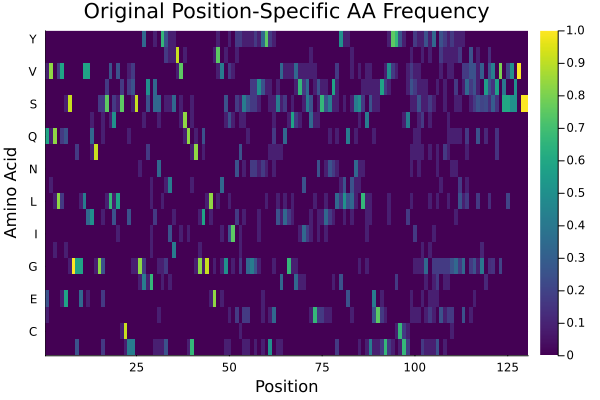

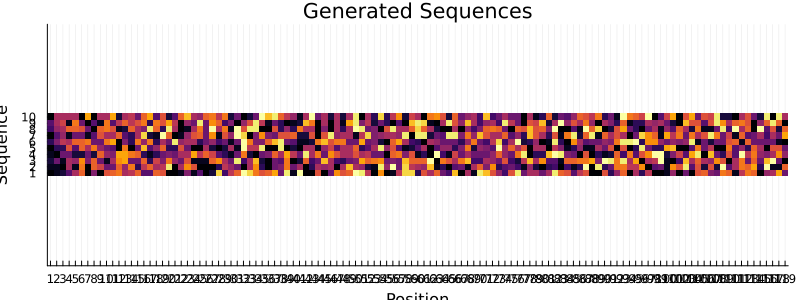

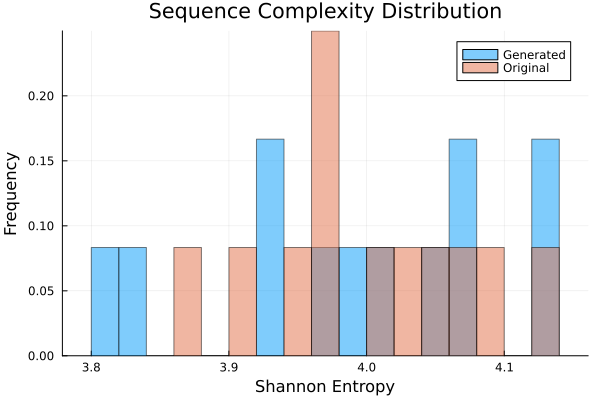

LoadError: UndefVarError: `z` not defined

In [61]:
using Plots
using StatsBase

# Function to convert one-hot encoded data back to sequences
function onehot_to_seq(onehot_data, aa_index)
    index_to_aa = Dict(v => k for (k, v) in aa_index)
    index_to_aa[0] = '-'  # Padding
    index_to_aa[length(aa_index) + 1] = 'X'  # Mask token
    
    seqs = []
    for i in 1:size(onehot_data, 3)
        seq = [index_to_aa[argmax(onehot_data[:, j, i]) - 1] for j in 1:size(onehot_data, 2)]
        push!(seqs, join(seq))
    end
    return seqs
end

# Convert generated samples to sequences
generated_seqs = onehot_to_seq(generated_samples, aa_to_index)
original_seqs = df.sequence_alignment_aa_heavy[1:min(length(generated_seqs), nrow(df))]

# 1. Sequence length distribution
function plot_length_distribution(gen_seqs, orig_seqs)
    gen_lengths = length.(gen_seqs)
    orig_lengths = length.(orig_seqs)
    p = histogram(gen_lengths, bins=20, alpha=0.5, label="Generated", normalize=:probability)
    histogram!(p, orig_lengths, bins=20, alpha=0.5, label="Original", normalize=:probability)
    title!("Sequence Length Distribution")
    xlabel!("Sequence Length")
    ylabel!("Frequency")
    return p
end

p1 = plot_length_distribution(generated_seqs, original_seqs)
display(p1)

# 2. Amino acid frequency
function plot_aa_frequency(gen_seqs, orig_seqs)
    gen_aa_freq = countmap(vcat(collect.(gen_seqs)...))
    orig_aa_freq = countmap(vcat(collect.(orig_seqs)...))
    all_aas = sort(unique(vcat(collect(keys(gen_aa_freq)), collect(keys(orig_aa_freq)))))
    
    gen_freqs = [get(gen_aa_freq, aa, 0) for aa in all_aas]
    orig_freqs = [get(orig_aa_freq, aa, 0) for aa in all_aas]
    
    p = bar(string.(all_aas), gen_freqs ./ sum(gen_freqs), alpha=0.5, label="Generated")
    bar!(p, string.(all_aas), orig_freqs ./ sum(orig_freqs), alpha=0.5, label="Original")
    title!("Amino Acid Frequency")
    xlabel!("Amino Acid")
    ylabel!("Relative Frequency")
    return p
end

p2 = plot_aa_frequency(generated_seqs, original_seqs)
display(p2)

# 3. Position-specific amino acid frequency
function plot_position_aa_freq(seqs, title)
    max_len = maximum(length.(seqs))
    unique_aas = sort(unique(vcat(collect.(seqs)...)))
    aa_freq = zeros(Int, length(unique_aas), max_len)
    for (i, seq) in enumerate(seqs)
        for (j, aa) in enumerate(seq)
            aa_freq[findfirst(==(aa), unique_aas), j] += 1
        end
    end
    aa_freq = aa_freq ./ sum(aa_freq, dims=1)
    heatmap(1:max_len, string.(unique_aas), aa_freq, 
            color=:viridis, title=title, xlabel="Position", ylabel="Amino Acid")
end

p3 = plot_position_aa_freq(generated_seqs, "Generated Position-Specific AA Frequency")
display(p3)
p4 = plot_position_aa_freq(original_seqs, "Original Position-Specific AA Frequency")
display(p4)

# 4. Visualization of generated sequences
function visualize_sequences(seqs, n=10)
    n = min(n, length(seqs))
    seqs_matrix = permutedims(hcat([collect(seq) for seq in seqs[1:n]]...))
    heatmap(seqs_matrix, 
            colorbar=false, 
            title="Generated Sequences", 
            xlabel="Position", 
            ylabel="Sequence",
            size=(800, 30*n),
            aspect_ratio=:equal,
            xticks=1:size(seqs_matrix, 2),
            yticks=(1:size(seqs_matrix, 1), 1:size(seqs_matrix, 1)))
end

p5 = visualize_sequences(generated_seqs)
display(p5)

# 5. Sequence complexity (Shannon entropy)
function sequence_entropy(seq)
    freq = countmap(seq)
    probs = values(freq) ./ length(seq)
    return -sum(p * log2(p) for p in probs)
end

function plot_sequence_complexity(gen_seqs, orig_seqs)
    gen_entropy = [sequence_entropy(seq) for seq in gen_seqs]
    orig_entropy = [sequence_entropy(seq) for seq in orig_seqs]
    p = histogram(gen_entropy, bins=20, alpha=0.5, label="Generated", normalize=:probability)
    histogram!(p, orig_entropy, bins=20, alpha=0.5, label="Original", normalize=:probability)
    title!("Sequence Complexity Distribution")
    xlabel!("Shannon Entropy")
    ylabel!("Frequency")
    return p
end

p6 = plot_sequence_complexity(generated_seqs, original_seqs)
display(p6)

# 6. Basic quantitative metrics
function compute_basic_metrics(gen_seqs, orig_seqs)
    avg_len_gen = mean(length.(gen_seqs))
    avg_len_orig = mean(length.(orig_seqs))
    z
    aa_diversity_gen = mean(length.(unique.(gen_seqs)))
    aa_diversity_orig = mean(length.(unique.(orig_seqs)))
    
    avg_entropy_gen = mean(sequence_entropy.(gen_seqs))
    avg_entropy_orig = mean(sequence_entropy.(orig_seqs))
    
    println("Average sequence length (generated): ", round(avg_len_gen, digits=2))
    println("Average sequence length (original): ", round(avg_len_orig, digits=2))
    println("Average amino acid diversity (generated): ", round(aa_diversity_gen, digits=2))
    println("Average amino acid diversity (original): ", round(aa_diversity_orig, digits=2))
    println("Average sequence entropy (generated): ", round(avg_entropy_gen, digits=2))
    println("Average sequence entropy (original): ", round(avg_entropy_orig, digits=2))
end

compute_basic_metrics(generated_seqs, original_seqs)

In [59]:
seqs = []
for antibody in generated_seqs
    push!(seqs, join([char for char in antibody if char != '-']))
end